# Testing Geoscience Australia's Sentinel-1 IW Backscatter to detect buildings - Casey station

This notebook is used to test detection of buildings at Casey station. A single image did not show the buildings clearly, so this notebook creates mean summer values to test this for persistency of high intensity areas associated with the buildings.

## Table of Contents
* Set-up
* Working with STAC
* Searching and loading
* Transforming and visualising
    * Visualising
    * Creating a mean for summer values
    * Converting to decibels
* Visualise to assess building detection
* Exporting

## Set-up

### Prepare the environment

You will need to install the required python packages, as described in the [README](README.md) file.

Once you have a python environment with the required libraries, connect the notebook to that environment.

### Import required libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from odc.stac import load, configure_s3_access
from odc.geo import BoundingBox
from odc.geo.xr import write_cog
import pathlib
from pystac_client import Client
import sys
sys.path.insert(1, '../../src/')
from speckle_filters import apply_lee_filter
import xarray as xr

## Working with STAC

STAC is a metadata standard and is commonly coupled with an API that allows users to query that metadata, making it easy to search for Earth observation datasets. 
DEA provide access to their STAC endpoint via Explorer.

The first step is to connect to DE's development STAC catalog, where the Sentinel-1 collection 0 data is housed.
The `pystac_client` python library is used to connect to the catalog.
Data is stored in Amazon Web Service's S3 service, and is free to access without an account.
The `odc_stac` python library is used to configure the required parameters for connecting to S3 without an account. 

In [2]:
catalog = "https://explorer.dev.dea.ga.gov.au/stac"

stac_client = Client.open(catalog)

configure_s3_access(
    cloud_defaults=True, 
    aws_unsigned=True,
)

### View available collections

GA's Sentinel-1 data is published according to the polarisation mode used to capture the data.
At this time, we publish data captured in Interferometric Wide (IW) mode. 
There are three products that we have experimental data for as part of our collection 0:
* VV+VH: `ga_s1_iw_vv_vh_c0`
* VV: `ga_s1_iw_vv_c0`
* HH: `ga_s1_iw_hh_c0`

You can see the distribution of captured data over time and space in the DEA Dev Explorer:
* [VV+VH distribution](https://explorer.dev.dea.ga.gov.au/products/ga_s1_iw_vv_vh_c0)
* [VV distribution](https://explorer.dev.dea.ga.gov.au/products/ga_s1_iw_vv_c0)
* [HH distribution](https://explorer.dev.dea.ga.gov.au/products/ga_s1_iw_hh_c0)

In [3]:
results = stac_client.collection_search(q="ga_s1*_c0")

collections = [result.id for result in results.collection_list()]

print(f"Available collections: {collections}")

AttributeError: 'Client' object has no attribute 'collection_search'

## Searching and Loading

This section provides examples for both Australia and Antarctica, as there are some differences between the two. 
Differences in polarisation are due to [Sentinel-1's observation scenarios](https://sentinels.copernicus.eu/copernicus/sentinel-1/acquisition-plans/observation-scenario-archive).
The table below captures the primary differences in the collection 0 offering:

| Property | Australia | Antarctica |
| --- | ----------- | ----------- |
| Primary capture mode | IW Vertical Dual-Polarisation (VV+VH) | IW Horizontal Single-Polarisation (HH) |
| Primary product | `ga_s1_iw_vv_vh_c0` | `ga_s1_iw_hh_c0` |
| Recommended CRS (metres) | UTM or EPSG:3577 | EPSG:3031 |
| Group by method | Solar day | Scene ID |

In Australia, there are a small number of IW Horizontal and Vertical Single-Polarisation acquisitions over south-east Queensland, but neither are the primary capture mode, and the collection 0 product only contains some data in 2024.

### Antarctica

Here, we use a bounding box over Casey Station near Law Dome, with a date range of Dec 2022 through Feb 2023.

In [4]:
ant_bbox = BoundingBox(
    left=110.50,
    bottom=-66.3,
    right=110.6,
    top=-66.2,
    crs="EPSG:4326"
)

summer_start_date = "2022-12-01"
summer_end_date = "2023-02-28"

The first step is to search for all observations that match these criteria, referred to as items in STAC. 

In [5]:
collections_query = ["ga_s1_iw_hh_c0"]
# ant_date_query = f"{ant_start_date}/{ant_end_date}"
ant_bbox_query = ant_bbox.bbox

ant_summer_items = stac_client.search(
    collections=collections_query,
    datetime=f"{summer_start_date}/{summer_end_date}",
    bbox=ant_bbox_query
).item_collection()

print(f"Found {len(ant_summer_items)} items")

Found 56 items


When working with GA's Sentinel-1 products, each item corresponds to a single burst, which is a subset of a scene.
The items contain the full STAC metadata, so information can be extracted from the properties.
For example, below demonstrates the number of unique scenes that the 10 bursts come from:

In [7]:
unique_scenes = set([item.properties["nrb:scene_id"][0] for item in ant_summer_items])

print(f"The identified items come from {len(unique_scenes)} unique scenes")

The identified items come from 1 unique scenes


Once the items have been identified, we use `odc-stac` to load them. 
With the `odc-stac` `load` command, you can specify:

* `crs`: the coordinate reference system (CRS) to project loaded data to. If not specified, the data's native CRS will be used.
* `resolution`: the resolution to load the data at, in the same units as the chosen CRS. If not specified, the data's native resolution will be used.
* `intersects`: a bounding box to clip the loaded data to. If not specified, the whole item will be loaded.
* `bands`: the measurements to load from the data (e.g. HH). If not specified, all measurements will be loaded.
* `groupby`: how to group loaded data. For Antarctica, the value `nrb:source_id` will ensure all bursts captured within a scene are grouped together under one time-stamp.
* `chunks={}`: request that the data be lazily loaded - an xarray showing the expected dimensions and measurements will be returned. Data will be computed when used. If not specified, data will be loaded into memory. 

> **Note:** When selecting a CRS for data over Antarctica, we recommend "EPSG:3031", which matches the data's native projection.

In [8]:
# Lazy load our filtered data
ant_ds = load(
    ant_summer_items,
    crs="EPSG:3031",
    resolution=20,
    intersects=ant_bbox.boundary(),
    bands=["HH", "mask"],
    groupby="nrb:scene_id",
    chunks={},
)

ant_ds

<xarray.Dataset> Size: 4GB
Dimensions:      (y: 6013, x: 5464, time: 16)
Coordinates:
  * y            (y) float64 48kB -8.384e+05 -8.385e+05 ... -9.587e+05
  * x            (x) float64 44kB 2.397e+06 2.397e+06 ... 2.506e+06 2.506e+06
    spatial_ref  int32 4B 3031
  * time         (time) datetime64[ns] 128B 2022-12-03T12:53:25.022685 ... 20...
Data variables:
    HH           (time, y, x) float32 2GB dask.array<chunksize=(1, 6013, 5464), meta=np.ndarray>
    mask         (time, y, x) float32 2GB dask.array<chunksize=(1, 6013, 5464), meta=np.ndarray>

### Loading data in memory

Once you have decided you are happy with the area of interest, crs, resolution, bands, etc., you can load data into memory using xarray's `.compute` operation. 

This is valuable once you are ready to apply transformations to the data, or wish to visualise the data, as it will save needing to read the data into memory every time.

In [9]:
ant_ds = ant_ds.compute()

## Transforming and visualising loaded data

The GA Sentinel-1 backscatter products are provided as linear gamma0 values. 
It is common to apply some transformations, such as masking, speckle filtering, and converting from linear scale to decibels. 
For collection 0, converting to other normalisation conventions (e.g. sigma0 and beta0) is not currently available.

If you need either sigma0 or beta0 for your work, please contact digitalearthantarctica@ga.gov.au with your request and information about your application to provide context about why you need an alternative normalisation convention. 
This helps us understand demand for these products, which may influence if we deliver them in future.

### Visualising

To see the full timeseries for a particular band, the following plotting command can be used:

#### Antarctica
The dark area corresponds to the glacier.
The bright segments are likely due to layover as there is significant terrain in this region.

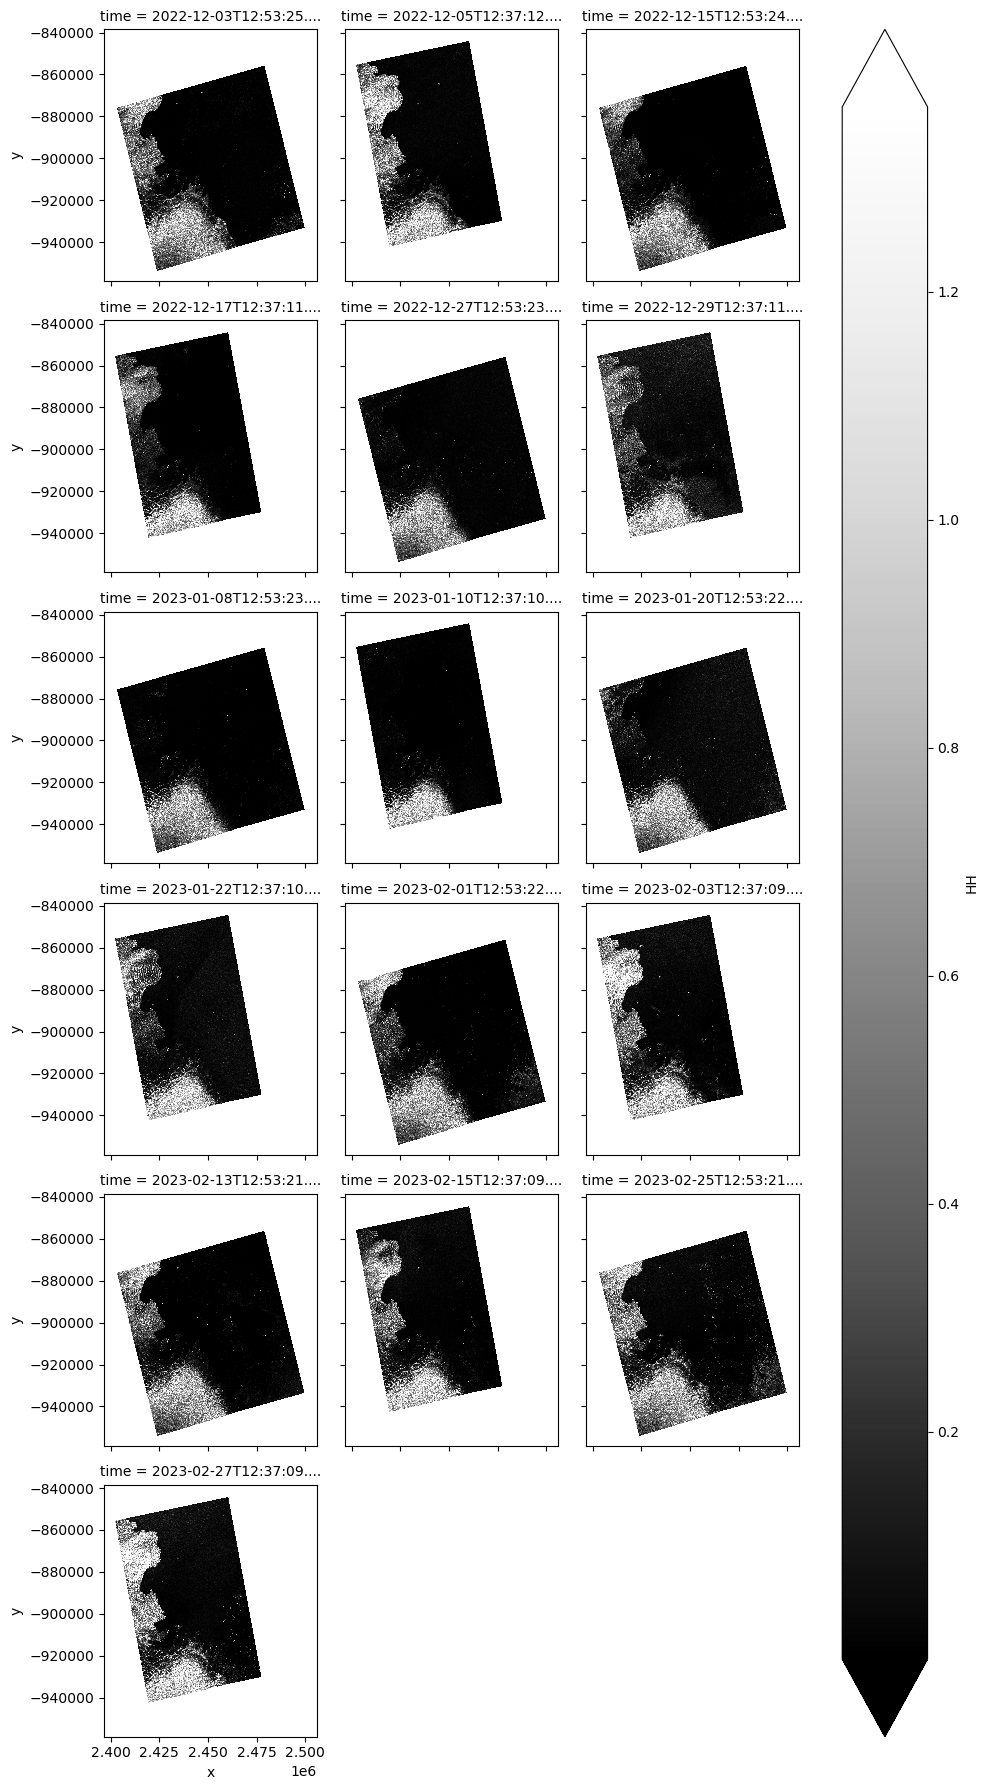

In [19]:
ant_ds.HH.plot.imshow(col="time", col_wrap=3, robust=True, cmap="Greys_r")

## Calculating the mean for all of the summer months

In [10]:
summer_mean = ant_ds.mean('time')

summer_mean

<xarray.Dataset> Size: 263MB
Dimensions:      (y: 6013, x: 5464)
Coordinates:
  * y            (y) float64 48kB -8.384e+05 -8.385e+05 ... -9.587e+05
  * x            (x) float64 44kB 2.397e+06 2.397e+06 ... 2.506e+06 2.506e+06
    spatial_ref  int32 4B 3031
Data variables:
    HH           (y, x) float32 131MB nan nan nan nan nan ... nan nan nan nan
    mask         (y, x) float32 131MB nan nan nan nan nan ... nan nan nan nan

# Converting to dB for summer mean
Note, for this mean dataset, no filtering or masking is required

In [11]:
summer_db = 10*np.log10(summer_mean)

/env/lib/python3.10/site-packages/xarray/core/computation.py:831: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


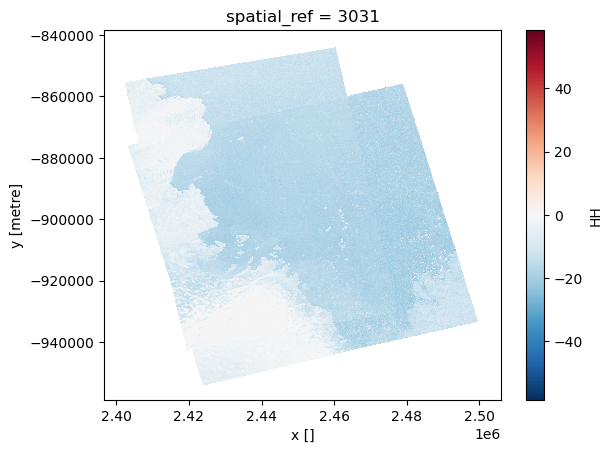

In [25]:
summer_db.HH.plot.imshow()

# Exporting mean summer data

In [12]:
# Set output path
output_path = pathlib.Path("outputs")
output_path.mkdir(exist_ok=True)

In [28]:
write_cog(
    summer_db.HH, 
    output_path / "LawDome_HH_mean_summer_2022-23.tif", 
    overwrite=True
)

PosixPath('outputs/LawDome_HH_mean_summer_2022-23.tif')